<a href="https://colab.research.google.com/github/ghadirchhade/Master-Thesis/blob/main/E06_ref_1_bbox%2Btiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [2]:
!pip install -q torch torchvision

In [3]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# facebook/sam3 is gated on the Hub -> you must accept the license at
# https://huggingface.co/facebook/sam3 with the account whose token you use below.
!pip install -q -U transformers accelerate huggingface_hub supervision

from huggingface_hub import login
login()  # paste your HF token (needs access to facebook/sam3)

print("Transformers SAM3 dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 8.7 MB/s eta 0:00:00
Transformers SAM3 dependencies installed.


In [6]:
import os
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import supervision as sv
import matplotlib.patches as patches
from transformers import Sam3Model, Sam3Processor

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sam3_model = Sam3Model.from_pretrained("facebook/sam3", device_map="auto")
sam3_model.eval()

sam3_processor = Sam3Processor.from_pretrained("facebook/sam3")

print("HF transformers SAM3 model + processor loaded.")
print("Model device:", next(sam3_model.parameters()).device)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

HF transformers SAM3 model + processor loaded.
Model device: cuda:0


In [10]:
IMAGE_PATH_target = "/content/drive/MyDrive/master thesis/AGS_Multi_Rumex/images/20230426_Wallenwil/DJI_20230426110736_0035.JPG"
LABEL_PATH_target ="/content/drive/MyDrive/master thesis/AGS_Multi_Rumex/annotations_yolo/DJI_20230426110736_0035.txt"

IMAGE_PATH_reference = "/content/drive/MyDrive/master thesis/AGS_Multi_Rumex/images/20230426_Wallenwil/DJI_20230426111205_0193.JPG"
LABEL_PATH_reference = "/content/drive/MyDrive/master thesis/AGS_Multi_Rumex/annotations_yolo/DJI_20230426111205_0193.txt"

RUMEX_CLASS_ID = 0

In [11]:
# Load TARGET image + GT boxes
target_image = Image.open(IMAGE_PATH_target).convert("RGB")
target_img_w, target_img_h = target_image.size
print(f"Target image size (W, H): {target_image.size}")

def load_yolo_boxes(label_path, img_width, img_height, class_id=0):
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls != class_id:
                continue
            xc, yc, bw, bh = map(float, parts[1:5])
            xc, yc, bw, bh = xc * img_width, yc * img_height, bw * img_width, bh * img_height
            boxes.append([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2])
    return np.array(boxes, dtype=np.float32)

gt_boxes_target = load_yolo_boxes(LABEL_PATH_target, target_img_w, target_img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes_target)} GT box(es) on TARGET image with class id={RUMEX_CLASS_ID}.")

Target image size (W, H): (8192, 5460)
Loaded 57 GT box(es) on TARGET image with class id=0.


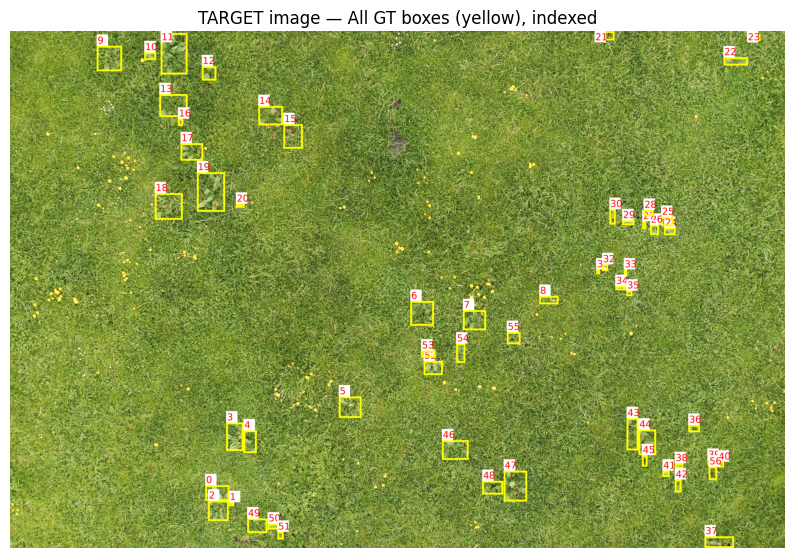

In [12]:
#  Visualize TARGET image GT boxes (indexed)
import matplotlib.font_manager as fm
font_path = fm.findfont("DejaVu Sans")
font = ImageFont.truetype(font_path, 100)

target_gt_preview = target_image.copy()
draw = ImageDraw.Draw(target_gt_preview)
for i, (x0, y0, x1, y1) in enumerate(gt_boxes_target):
    draw.rectangle([x0, y0, x1, y1], outline=(255, 255, 0), width=20)
    text_x, text_y = int(x0), max(0, int(y0) - 120)
    draw.rectangle([text_x, text_y, text_x + 120, text_y + 120], fill=(255, 255, 255))
    draw.text((text_x + 10, text_y + 5), str(i), fill=(255, 0, 0), font=font)

plt.figure(figsize=(10, 8))
plt.imshow(target_gt_preview)
plt.title("TARGET image — All GT boxes (yellow), indexed")
plt.axis("off")
plt.show()

In [13]:
# Load REFERENCE image + GT boxes
reference_image = Image.open(IMAGE_PATH_reference).convert("RGB")
ref_img_w, ref_img_h = reference_image.size
print(f"Reference image size (W, H): {reference_image.size}")

gt_boxes = load_yolo_boxes(LABEL_PATH_reference, ref_img_w, ref_img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes)} GT box(es) on REFERENCE image with class id={RUMEX_CLASS_ID}.")

Reference image size (W, H): (8192, 5460)
Loaded 48 GT box(es) on REFERENCE image with class id=0.


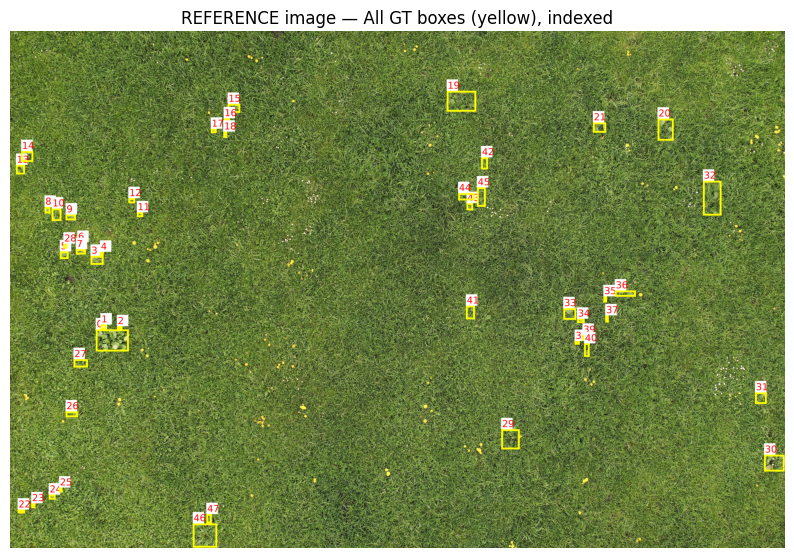

In [14]:
# Visualize REFERENCE image GT boxes (indexed)
ref_gt_preview = reference_image.copy()
draw = ImageDraw.Draw(ref_gt_preview)
for i, (x0, y0, x1, y1) in enumerate(gt_boxes):
    draw.rectangle([x0, y0, x1, y1], outline=(255, 255, 0), width=20)
    text_x, text_y = int(x0), max(0, int(y0) - 120)
    draw.rectangle([text_x, text_y, text_x + 120, text_y + 120], fill=(255, 255, 255))
    draw.text((text_x + 10, text_y + 5), str(i), fill=(255, 0, 0), font=font)

plt.figure(figsize=(10, 8))
plt.imshow(ref_gt_preview)
plt.title("REFERENCE image — All GT boxes (yellow), indexed")
plt.axis("off")
plt.show()

Exemplar index: 0
Exemplar box (x1, y1, x2, y2): [906.0399780273438, 3151.64892578125, 1256.135986328125, 3384.007080078125]


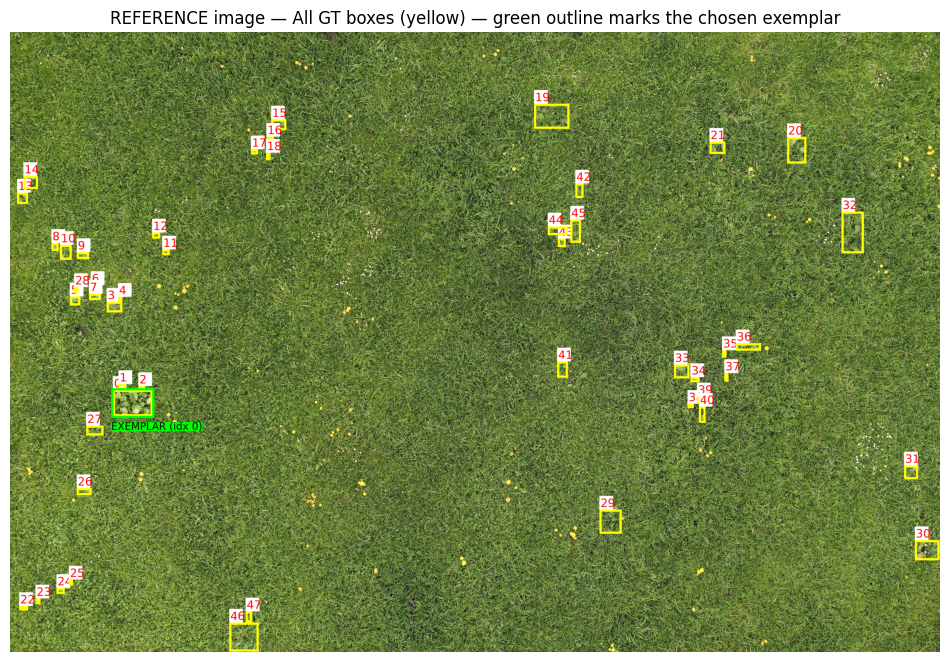

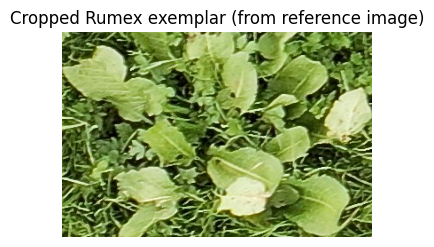

In [30]:
# Choose the exemplar by index (from REFERENCE image GT), crop it,
# and highlight it against all reference GT boxes
exemplar_index = 0   # <-- edit: index into gt_boxes (reference image) to use as the exemplar
ex_x0, ex_y0, ex_x1, ex_y1 = gt_boxes[exemplar_index]
ref_box_xyxy = [float(ex_x0), float(ex_y0), float(ex_x1), float(ex_y1)]
rumex_crop = reference_image.crop([int(round(v)) for v in ref_box_xyxy])

print(f"Exemplar index: {exemplar_index}")
print(f"Exemplar box (x1, y1, x2, y2): {ref_box_xyxy}")

# All GT boxes (yellow) + the chosen exemplar highlighted (green outline on top)
exemplar_preview = reference_image.copy()
draw = ImageDraw.Draw(exemplar_preview)

for i, (bx0, by0, bx1, by1) in enumerate(gt_boxes):
    draw.rectangle([bx0, by0, bx1, by1], outline=(255, 255, 0), width=20)
    text_x, text_y = int(bx0), max(0, int(by0) - 120)
    draw.rectangle([text_x, text_y, text_x + 120, text_y + 120], fill=(255, 255, 255))
    draw.text((text_x + 10, text_y + 5), str(i), fill=(255, 0, 0), font=font)

HIGHLIGHT_PAD = 15
draw.rectangle(
    [ex_x0 - HIGHLIGHT_PAD, ex_y0 - HIGHLIGHT_PAD, ex_x1 + HIGHLIGHT_PAD, ex_y1 + HIGHLIGHT_PAD],
    outline=(0, 255, 0), width=20,
)
label_text = f"EXEMPLAR (idx {exemplar_index})"
label_x, label_y = int(ex_x0 - HIGHLIGHT_PAD), int(ex_y1 + HIGHLIGHT_PAD + 20)
label_font = ImageFont.truetype(font_path, 90)
text_bbox = draw.textbbox((label_x, label_y), label_text, font=label_font)
draw.rectangle(text_bbox, fill=(0, 255, 0))
draw.text((label_x, label_y), label_text, fill=(0, 0, 0), font=label_font)

plt.figure(figsize=(12, 10))
plt.imshow(exemplar_preview)
plt.axis("off")
plt.title("REFERENCE image — All GT boxes (yellow) — green outline marks the chosen exemplar")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(rumex_crop)
plt.axis("off")
plt.title("Cropped Rumex exemplar (from reference image)")
plt.show()

In [31]:
# Helper functions: background patch, feather mask
def get_local_background_patch(tile_img: Image.Image, patch_w: int, patch_h: int) -> Image.Image:
    """
    Sample REAL texture from the tile itself for the strip's background, so color
    balance/brightness/grain match this tile's own lighting, and there's no
    artificial white-vs-photo boundary for the vision transformer to latch onto.
    """
    sample = tile_img.crop((0, 0, min(patch_w, tile_img.width), min(patch_h, tile_img.height)))
    if sample.size != (patch_w, patch_h):
        sample = sample.resize((patch_w, patch_h))
    return sample


def make_feather_mask(size, feather_width: int = 8) -> Image.Image:
    """
    Grayscale alpha mask: interior = 255 (opaque), border band ramps to 0, so the
    pasted exemplar blends smoothly instead of leaving a hard rectangular seam.
    """
    w, h = size
    mask = np.full((h, w), 255, dtype=np.float32)
    for i in range(feather_width):
        alpha = 255.0 * (i + 1) / feather_width
        mask[i, :] = np.minimum(mask[i, :], alpha)
        mask[h - 1 - i, :] = np.minimum(mask[h - 1 - i, :], alpha)
        mask[:, i] = np.minimum(mask[:, i], alpha)
        mask[:, w - 1 - i] = np.minimum(mask[:, w - 1 - i], alpha)
    return Image.fromarray(mask.astype(np.uint8), mode="L")

In [32]:
# Compose tile with exemplar
def compose_tile_with_exemplar(tile_img: Image.Image, crop_image: Image.Image,
                                margin: int = 6, feather_width: int = 8):
    """
    Builds the composed image sent to SAM3 for ONE tile.
    Returns:
        composed -- the image to feed to SAM3
        crop_box -- [x1,y1,x2,y2] of the exemplar in composed-image coords
        offset   -- (dx, dy) to convert composed target-region coords back
                    to this TILE's own coordinate system
    """
    strip_h = crop_image.height + 2 * margin
    canvas_w = max(tile_img.width, crop_image.width + 2 * margin)
    canvas_h = strip_h + tile_img.height

    strip_bg = get_local_background_patch(tile_img, canvas_w, strip_h)

    composed = Image.new("RGB", (canvas_w, canvas_h))
    composed.paste(strip_bg, (0, 0))
    offset = (0, strip_h)
    composed.paste(tile_img, offset)

    feather_mask = make_feather_mask(crop_image.size, feather_width=feather_width)
    paste_xy = (margin, margin)
    composed.paste(crop_image, paste_xy, feather_mask)

    crop_box = [
        paste_xy[0], paste_xy[1],
        paste_xy[0] + crop_image.width, paste_xy[1] + crop_image.height,
    ]
    return composed, crop_box, offset

In [33]:
#Tiling helper
def tile_bboxes(img_w: int, img_h: int, tile_size: int, overlap: int):
    """
    Generates (x1,y1,x2,y2) windows covering the whole image, with overlap so plants
    sitting right on a tile boundary aren't missed or half-cut in every window.
    """
    step = tile_size - overlap
    tiles = []
    for y in range(0, img_h, step):
        for x in range(0, img_w, step):
            x2 = min(x + tile_size, img_w)
            y2 = min(y + tile_size, img_h)
            x1 = max(0, x2 - tile_size)
            y1 = max(0, y2 - tile_size)
            tiles.append((x1, y1, x2, y2))
    return list(dict.fromkeys(tiles))

In [34]:
# Padding-region filter
def keep_only_target_region_detections(boxes, scores, masks, offset, y_tolerance=5):
    """
    Drop any detection sitting inside the padding strip (that's the pasted exemplar
    being re-detected, not a real find), keep only detections that fall within the
    tile's real-content region, and remap coordinates back to the tile's own system.
    """
    dx, dy = offset
    kept_boxes, kept_scores, kept_masks = [], [], []

    for box, score, mask in zip(boxes, scores, masks):
        x1, y1, x2, y2 = box.tolist() if torch.is_tensor(box) else box
        if y1 >= dy - y_tolerance:
            remapped_box = [x1 - dx, max(y1 - dy, 0), x2 - dx, y2 - dy]
            kept_boxes.append(remapped_box)
            kept_scores.append(score)
            mask_np = mask.cpu().numpy() if torch.is_tensor(mask) else mask
            kept_masks.append(mask_np[dy:, dx:] if dx or dy else mask_np)

    return kept_boxes, kept_scores, kept_masks

In [35]:
# Run SAM3 on one tile (box-exemplar only, no text prompt)
def run_sam3_on_tile(composed_tile, crop_box, offset, threshold=0.3):
    """
    Box-exemplar-only inference (no text prompt).
    """
    inputs = sam3_processor(
        images=composed_tile,
        input_boxes=[[crop_box]],
        input_boxes_labels=[[1]],
        return_tensors="pt",
    ).to(sam3_model.device)

    with torch.no_grad():
        outputs = sam3_model(**inputs)

    results = sam3_processor.post_process_instance_segmentation(
        outputs, threshold=threshold, mask_threshold=0.4,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]

    return keep_only_target_region_detections(
        results["boxes"], results["scores"], results["masks"], offset
    )

In [36]:
# Implausible-box filter
def filter_implausible_boxes(boxes, scores, masks, tile_w, tile_h,
                              min_fill_ratio=0.15, max_area_fraction=0.6, edge_margin=5):
    """
    Rejects phantom "whole scene" detections using mask shape rather than absolute
    size, since real plants legitimately vary a lot in size.
    """
    kept_boxes, kept_scores, kept_masks = [], [], []

    for box, score, mask in zip(boxes, scores, masks):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        box_area = max(w * h, 1)

        mask_np = mask.cpu().numpy() if torch.is_tensor(mask) else mask
        mask_area = float((mask_np > 0.5).sum())
        fill_ratio = mask_area / box_area

        if fill_ratio < min_fill_ratio:
            continue

        touches_edges = sum([
            x1 <= edge_margin,
            y1 <= edge_margin,
            x2 >= tile_w - edge_margin,
            y2 >= tile_h - edge_margin,
        ])
        if box_area > max_area_fraction * tile_w * tile_h and touches_edges >= 3:
            continue

        kept_boxes.append(box)
        kept_scores.append(score)
        kept_masks.append(mask)

    return kept_boxes, kept_scores, kept_masks

In [37]:
# NMS merge across overlapping tiles
def nms_merge(boxes, scores, masks, iou_thresh: float = 0.5):
    """
    Because tiles overlap, the same real plant can get detected in two neighboring
    tiles. IoU-based NMS collapses duplicates to the single highest-confidence box,
    carrying the matching mask through too.
    """
    if not boxes:
        return [], [], []

    boxes_t = torch.tensor(boxes, dtype=torch.float32)
    scores_t = torch.tensor([s.item() if torch.is_tensor(s) else s for s in scores])
    order = scores_t.argsort(descending=True)
    keep = []

    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]
        xx1 = torch.maximum(boxes_t[i, 0], boxes_t[rest, 0])
        yy1 = torch.maximum(boxes_t[i, 1], boxes_t[rest, 1])
        xx2 = torch.minimum(boxes_t[i, 2], boxes_t[rest, 2])
        yy2 = torch.minimum(boxes_t[i, 3], boxes_t[rest, 3])
        inter = (xx2 - xx1).clamp(0) * (yy2 - yy1).clamp(0)
        area_i = (boxes_t[i, 2] - boxes_t[i, 0]) * (boxes_t[i, 3] - boxes_t[i, 1])
        area_r = (boxes_t[rest, 2] - boxes_t[rest, 0]) * (boxes_t[rest, 3] - boxes_t[rest, 1])
        iou = inter / (area_i + area_r - inter + 1e-6)
        order = rest[iou <= iou_thresh]

    kept_boxes = [boxes[i] for i in keep]
    kept_scores = [scores[i] for i in keep]
    kept_masks = [masks[i] for i in keep]
    return kept_boxes, kept_scores, kept_masks

In [38]:
# Display helper (predictions + optional GT overlay)
def show_image_with_boxes(image: Image.Image, boxes_xyxy, masks=None, scores=None,
                           gt_boxes_xyxy=None, title=""):
    """
    masks: list of (mask_np, ox, oy) tuples in TILE-local pixel space, placed at
    (ox, oy) in the full image via matplotlib's `extent`.
    gt_boxes_xyxy: optional array of ground-truth boxes to overlay in yellow
    alongside the (lime) predictions.
    """
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image)
    ax.set_xlim(0, image.width)
    ax.set_ylim(image.height, 0)

    rng = np.random.default_rng(0)

    if masks is not None:
        for (mask_np, ox, oy) in masks:
            color = rng.uniform(0.2, 1.0, size=3)
            mask_np = mask_np.cpu().numpy() if torch.is_tensor(mask_np) else mask_np
            h, w = mask_np.shape[:2]
            overlay = np.zeros((h, w, 4))
            overlay[mask_np > 0.5] = (*color, 0.45)
            ax.imshow(overlay, extent=[ox, ox + w, oy + h, oy])

    if gt_boxes_xyxy is not None:
        for gx1, gy1, gx2, gy2 in gt_boxes_xyxy:
            rect = patches.Rectangle(
                (gx1, gy1), gx2 - gx1, gy2 - gy1,
                linewidth=2, edgecolor="yellow", facecolor="none",
            )
            ax.add_patch(rect)

    for i, box in enumerate(boxes_xyxy):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        if scores is not None:
            ax.text(
                x1, y1 - 5, f"{scores[i]:.2f}",
                color="lime", fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"),
            )

    ax.set_title(title)
    ax.axis("off")
    plt.show()

Tile region in target image: (0, 0) -> (1000, 1000)
Tile size (W, H): (1000, 1000)
Composed image size (W, H): (1000, 1244)
Exemplar box in composed-image coords: [6, 6, 356, 238]
Offset (tile content start in composed image): (0, 244)


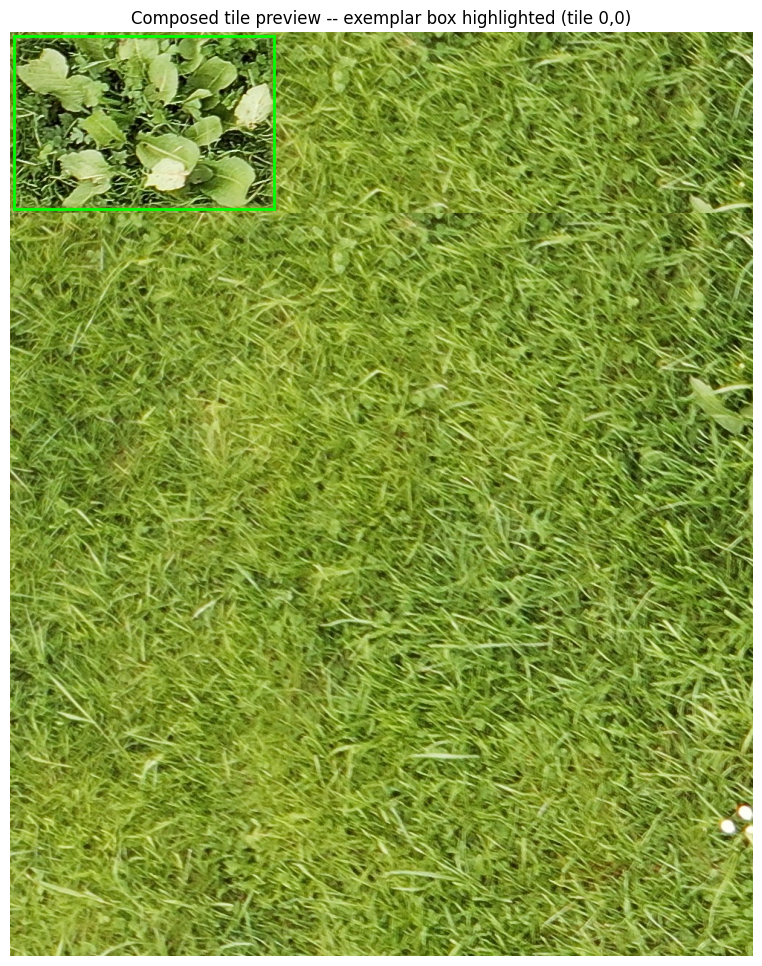

In [39]:
#  Preview one composed tile (from TARGET image, auto-picks the tile
# nearest the exemplar's own location if it happens to overlap; otherwise
# just previews the first tile since the exemplar comes from a DIFFERENT image)
TILE_SIZE = 1000
OVERLAP = 150

all_tiles = tile_bboxes(target_image.width, target_image.height, TILE_SIZE, OVERLAP)
preview_x1, preview_y1, preview_x2, preview_y2 = all_tiles[0]

preview_tile = target_image.crop((preview_x1, preview_y1, preview_x2, preview_y2))

composed_preview, crop_box_preview, offset_preview = compose_tile_with_exemplar(
    preview_tile, rumex_crop, margin=6, feather_width=8
)

print(f"Tile region in target image: ({preview_x1}, {preview_y1}) -> ({preview_x2}, {preview_y2})")
print(f"Tile size (W, H): {preview_tile.size}")
print(f"Composed image size (W, H): {composed_preview.size}")
print(f"Exemplar box in composed-image coords: {crop_box_preview}")
print(f"Offset (tile content start in composed image): {offset_preview}")

if composed_preview.width != preview_tile.width:
    print(f"WARNING: composed width ({composed_preview.width}) != tile width "
          f"({preview_tile.width}) -- coordinate mismatch risk for this tile.")

show_image_with_boxes(
    composed_preview,
    boxes_xyxy=[crop_box_preview],
    title=f"Composed tile preview -- exemplar box highlighted (tile {preview_x1},{preview_y1})",
)

In [40]:
# Main inference pipeline (box-exemplar only, no text prompt) on TARGET image
"""
Split the TARGET drone image into overlapping tiles.
Add the Rumex exemplar crop (from the REFERENCE image) as a visual prompt to each tile.
Run SAM3 on each composed tile.
Remove implausible / padding-region detections.
Convert tile-local detections back into original TARGET image coordinates.
Merge duplicate detections caused by tile overlap.
"""
all_boxes, all_scores, all_masks = [], [], []

for (x1, y1, x2, y2) in tile_bboxes(target_image.width, target_image.height, TILE_SIZE, OVERLAP):
    tile = target_image.crop((x1, y1, x2, y2))

    composed_tile, crop_box, offset = compose_tile_with_exemplar(
        tile, rumex_crop, margin=6, feather_width=8
    )

    boxes, scores, masks = run_sam3_on_tile(
        composed_tile, crop_box, offset,
        threshold=0.3,
    )

    tile_w, tile_h = x2 - x1, y2 - y1
    boxes, scores, masks = filter_implausible_boxes(
        boxes, scores, masks, tile_w, tile_h,
        min_fill_ratio=0.15, max_area_fraction=0.6, edge_margin=5,
    )

    for b, s, m in zip(boxes, scores, masks):
        all_boxes.append([b[0] + x1, b[1] + y1, b[2] + x1, b[3] + y1])
        all_scores.append(s.item() if torch.is_tensor(s) else s)
        all_masks.append((m, x1, y1))

final_boxes, final_scores, final_masks = nms_merge(all_boxes, all_scores, all_masks, iou_thresh=0.5)

print(f"Total Rumex instances found: {len(final_boxes)}")
for i, (box, score) in enumerate(zip(final_boxes, final_scores)):
    print(f"  instance {i}: confidence={score:.3f}, box={[round(v, 1) for v in box]}")

Total Rumex instances found: 49
  instance 0: confidence=0.890, box=[5099.6, 4643.0, 5465.2, 4969.5]
  instance 1: confidence=0.780, box=[6523.4, 4093.5, 6831.6, 4398.6]
  instance 2: confidence=0.767, box=[7346.9, 5337.8, 7641.0, 5457.9]
  instance 3: confidence=0.754, box=[1699.1, 20.5, 1878.8, 294.2]
  instance 4: confidence=0.741, box=[2285.6, 4140.5, 2560.7, 4399.2]
  instance 5: confidence=0.714, box=[4988.9, 4745.2, 5256.4, 4956.9]
  instance 6: confidence=0.674, box=[2565.7, 5147.4, 2839.6, 5247.7]
  instance 7: confidence=0.651, box=[4560.7, 4317.1, 4847.4, 4530.3]
  instance 8: confidence=0.634, box=[1980.3, 1504.7, 2267.8, 1849.5]
  instance 9: confidence=0.605, box=[4233.5, 2851.6, 4409.7, 3111.3]
  instance 10: confidence=0.603, box=[1700.5, 664.6, 1883.5, 999.0]
  instance 11: confidence=0.592, box=[1980.2, 1700, 2279.6, 1905.8]
  instance 12: confidence=0.590, box=[2063.6, 4793.8, 2340.4, 5179.1]
  instance 13: confidence=0.556, box=[2627.3, 923.1, 2704.6, 997.5]
  insta

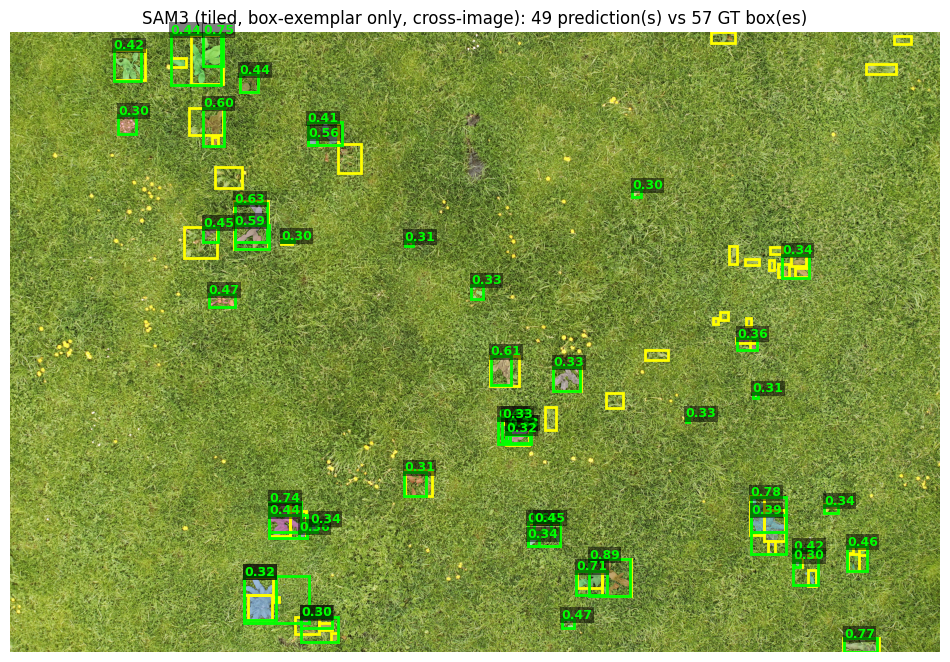

In [41]:
#  Display final predictions (lime) vs TARGET image GT boxes (yellow)
show_image_with_boxes(
    target_image,
    boxes_xyxy=final_boxes,
    masks=final_masks,
    scores=final_scores,
    gt_boxes_xyxy=gt_boxes_target,
    title=(f"SAM3 (tiled, box-exemplar only, cross-image): "
           f"{len(final_boxes)} prediction(s) vs {len(gt_boxes_target)} GT box(es)"),
)

In [42]:
# Compute detection metrics (box-based) against TARGET image GT
pred_boxes_np = np.array(final_boxes, dtype=np.float32) if final_boxes else np.zeros((0, 4), dtype=np.float32)
pred_scores_np = np.array(final_scores, dtype=np.float32) if final_scores else np.zeros((0,), dtype=np.float32)

pred_detections = sv.Detections(
    xyxy=pred_boxes_np,
    confidence=pred_scores_np,
    class_id=np.zeros(len(pred_scores_np), dtype=int),
)
gt_detections = sv.Detections(
    xyxy=gt_boxes_target,
    class_id=np.zeros(len(gt_boxes_target), dtype=int),
)

from supervision.metrics import MeanAveragePrecision

map_metric = MeanAveragePrecision()
result = map_metric.update([pred_detections], [gt_detections]).compute()
print(f"mAP50: {result.map50:.4f}")

def compute_iou_matrix(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])
    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    inter_area = inter_w * inter_h
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2[None, :] - inter_area
    return np.where(union_area > 0, inter_area / union_area, 0.0)

IOU_THRESHOLD = 0.5
iou_matrix = compute_iou_matrix(pred_boxes_np, gt_boxes_target)
num_preds, num_gt = len(pred_boxes_np), len(gt_boxes_target)

matched_gt = set()
true_positives = 0
matched_ious = []
pred_order = np.argsort(-pred_scores_np) if num_preds > 0 else []

for pred_idx in pred_order:
    if num_gt == 0:
        break
    best_gt_idx = np.argmax(iou_matrix[pred_idx])
    best_iou = iou_matrix[pred_idx, best_gt_idx]
    if best_iou >= IOU_THRESHOLD and best_gt_idx not in matched_gt:
        matched_gt.add(best_gt_idx)
        true_positives += 1
        matched_ious.append(best_iou)

false_positives = num_preds - true_positives
false_negatives = num_gt - true_positives
precision = true_positives / num_preds if num_preds > 0 else 0.0
recall = true_positives / num_gt if num_gt > 0 else 0.0
mean_iou_matched = float(np.mean(matched_ious)) if matched_ious else 0.0
mean_iou_all_gt = float(np.sum(matched_ious) / num_gt) if num_gt > 0 else 0.0

print(f"IoU threshold: {IOU_THRESHOLD}")
print(f"Num predictions: {num_preds} | Num GT boxes: {num_gt}")
print(f"True Positives:  {true_positives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Mean IoU (matched pairs only): {mean_iou_matched:.4f}")
print(f"Mean IoU (over all GT boxes):  {mean_iou_all_gt:.4f}")

mAP50: 0.1603
IoU threshold: 0.5
Num predictions: 49 | Num GT boxes: 57
True Positives:  16
False Positives: 33
False Negatives: 41
Precision: 0.3265
Recall:    0.2807
Mean IoU (matched pairs only): 0.7752
Mean IoU (over all GT boxes):  0.2176
